In [1]:
import sys
sys.path.append('../')
from fluProfiler_models import fluProfiler_Config, fluProfiler_HANA
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm
import json
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import pandas as pd
import torch.nn.functional as F
import numpy as np
from utilities import load_embedding, EarlyStopping
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from datetime import datetime
import pickle
from utilities import print_exams
import matplotlib.pyplot as plt

class fluProfiler_Dataset(Dataset):
    def __init__(self, DataFrame):
        self.emb_file_name_a = ('matrix_' + DataFrame['seq_id_a']).tolist()
        self.emb_file_name_b = ('matrix_' + DataFrame['seq_id_b']).tolist()
        self.emb_file_name_c = ('matrix_' + DataFrame['seq_id_c']).tolist()
        self.emb_file_name_d = ('matrix_' + DataFrame['seq_id_d']).tolist()

        self.strainPassCats = convert_Pass2tensor(('<cls>' + DataFrame['serumPassCat'] + '<eos>' + DataFrame['virusPassCat'] + '<eos>').tolist())

        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.emb_file_name_a[idx], self.emb_file_name_b[idx], self.emb_file_name_c[idx], self.emb_file_name_d[idx], \
               self.strainPassCats[idx], self.labels[idx]

def convert_Pass2tensor(pass_cats):
    result = [
        item.replace('<cls>', '0').replace('<eos>', '1').replace('<EGG>', '2').replace('<CELL>', '3').replace('<BOTH>', '4')
        for item in pass_cats
    ]
    result = torch.tensor([[int(number) for number in [char for char in item]] for item in result])
    return result

def generate_matrix(matrix_list):
    seq_len = [mat.shape[0] for mat in matrix_list]
    max_len = max(seq_len)
    mask_list = []
    for i in range(len(matrix_list)): 
        matrix_list[i] = F.pad(matrix_list[i], (0, 0, 0, max_len - seq_len[i]))
        mask = torch.concat((torch.ones(1,seq_len[i]),torch.zeros(1,max_len-seq_len[i])),axis=1)
        mask_list.append(mask)
    matrix = torch.stack(matrix_list)
    mask = torch.stack(mask_list).view(len(matrix_list),max_len)
    return matrix, mask

## 1. Vaccine recommendation for 2024NH

In [2]:
device = torch.device('cuda:1')
Crick_early = pd.read_csv('../../data/data_40/all.csv')
Crick_2024NH = pd.read_csv('../../data/data_40/Vaccination.csv')
Crick_2024NH['seq_id_a'] = Crick_2024NH['seq_id_a'] + '_2024NH'
Crick_2024NH['seq_id_b'] = Crick_2024NH['seq_id_b'] + '_2024NH'
Crick_2024NH['seq_id_c'] = Crick_2024NH['seq_id_c'] + '_2024NH'
Crick_2024NH['seq_id_d'] = Crick_2024NH['seq_id_d'] + '_2024NH'

In [3]:
## serum selection
candidate_df = pd.concat([Crick_early, Crick_2024NH])
groupby_columns = ['seq_a', 'seq_b', 'serumPassCat']
agg_dict = {'seq_id_a': 'first', 'seq_id_b': 'first', 'label': 'mean', 'serumName': 'first', 'serumIslID': 'first'}
H1_serum = candidate_df.loc[candidate_df['Type'] == 'H1N1'].groupby(groupby_columns).agg(agg_dict).reset_index()
H3_serum = candidate_df.loc[candidate_df['Type'] == 'H3N2'].groupby(groupby_columns).agg(agg_dict).reset_index()
## virus selection
groupby_columns = ['seq_c', 'seq_d', 'virusPassCat']
agg_dict = {'seq_id_c': 'first', 'seq_id_d': 'first', 'HI_Dist': 'mean', 'virusName': 'first', 'virusIslID': 'first'}
H1_virus = Crick_2024NH.loc[Crick_2024NH['serumType'] == 'H1N1'].groupby(groupby_columns).agg(agg_dict).reset_index()
H3_virus = Crick_2024NH.loc[Crick_2024NH['serumType'] == 'H3N2'].groupby(groupby_columns).agg(agg_dict).reset_index()

In [6]:
seq_names = pd.concat([H3_serum['seq_id_a'], H3_serum['seq_id_b'], H3_virus['seq_id_c'], H3_virus['seq_id_d']]).unique().tolist()
file_names = ['matrix_' + ID + '.pt' for ID in seq_names]
file_names_early  = [f for f in file_names if "_2024NH" not in f]
file_names_2024NH = [f for f in file_names if "_2024NH" in f]

In [7]:
emb_dict_early = load_embedding('../../data/data_40/embedding_Crick', files=file_names_early, map_location=device)
emb_dict_2024NH = load_embedding('../../data/data_40/embedding_vac',files=[f.replace('_2024NH', '') for f in file_names_2024NH],map_location=device)
emb_dict_2024NH = {key + '_2024NH': value for key, value in emb_dict_2024NH.items()}

emb_dict = emb_dict_early | emb_dict_2024NH

Loading tensor: 100%|██████████| 246/246 [00:12<00:00, 19.84file/s]


In [8]:
test_df = H3_serum.merge(H3_virus, how='cross')
test_df['label'] = 0
test_dataset = fluProfiler_Dataset(test_df)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [9]:
model = torch.load('../../trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
prediction_ls_test = []
reference_ls_test = []
logits_ls = []
loss_ls_test = []
model.eval()
for batch in test_dataloader:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch

    matrixs_a, masks_a = generate_matrix([emb_dict[key] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict[key] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in emb_file_name_d])

    matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)

    strainPassCats = strainPassCats.to(device)

    labels = labels.to(device)
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c,
                                        matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b,
                                        matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats,
                                        labels=labels)

    loss_ls_test.append(loss.item())
    logits_ls.append(logits.tolist())
    prediction_ls_test.extend(output.view(-1).tolist())
    reference_ls_test.extend(labels.tolist())

test_mae, test_mse, test_pearson, test_spearman, test_R2 = print_exams(reference_ls_test, prediction_ls_test)
test_df['prediction'] = prediction_ls_test

MAE: 3.00898
MSE: 10.60054
pearson correlation: nan
spearman correlation: nan
R2_score: -5.67630


/mnt/zzbnew/peixunban/chenyihao/fluProfiler/src/Section3_Vaccine_recommendation/../utilities.py:72: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  MAE, MSE, Pearson, Spearman, R2 = mean_absolute_error(O, P), mean_squared_error(O, P), pearsonr(O, P), spearmanr(O, P), r2_score(O, P)


In [17]:
vaccine = test_df.groupby(['seq_a', 'seq_b', 'serumPassCat']).agg({'prediction': 'mean', 'serumName': 'first', 'serumIslID': 'first'}).reset_index()
vaccine['vaccine'] = vaccine['serumName'] + ' ' + vaccine['serumPassCat'].str.replace('<', '').str.replace('>', '')
vaccine['prediction'] = vaccine['prediction'] * -1
vaccine = vaccine.sort_values(by='prediction', ascending=False)
# vaccine.to_csv('../../Figure/Table S1.csv', index=False)

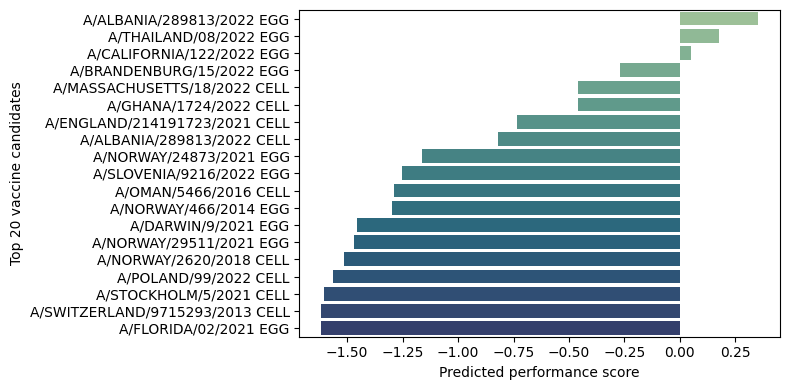

In [19]:
# 取预测分数最高的前 20 个疫苗
top20 = vaccine.sort_values('prediction', ascending=False).head(20)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=top20,
    y='vaccine',
    x='prediction',
    palette='crest',
    errorbar=None
)

plt.xlabel('Predicted performance score')
plt.ylabel('Top 20 vaccine candidates')
plt.tight_layout()
plt.show()


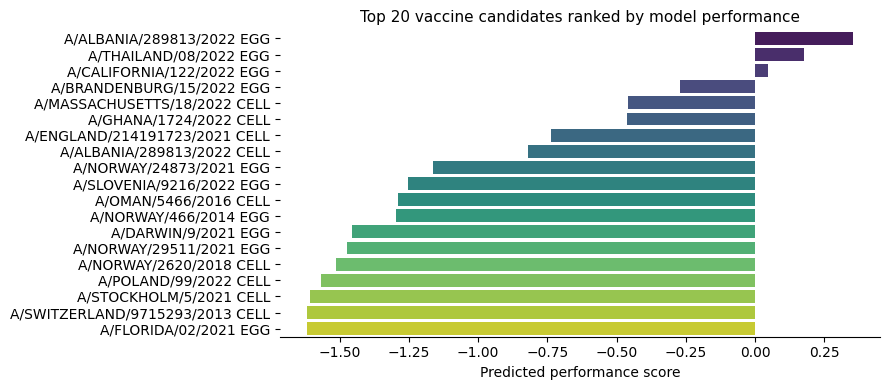

In [68]:
plt.figure(figsize=(9,4))
top20 = vaccine.sort_values('prediction', ascending=False).head(20)
sns.barplot(
    data=top20,
    y='vaccine',
    x='prediction',
    # order=top20['serumName'],
    palette='viridis',
    errorbar=None
)
sns.despine(left=True)
plt.xlabel('Predicted performance score', fontsize=10)
plt.ylabel('')
plt.title('Top 20 vaccine candidates ranked by model performance', fontsize=11)
plt.tight_layout()
